# Supplementary Figure S41: `s41_adv_sensitivity_formulations`

**Alternative metrics for estimating adversarial sensitivity and gradient spectral concentration.** We find that while adversarial sensitivity correlates with control over the full model set, the relationship diminishes once the adversarially trained models are removed, and this trend replicates across essentially every tested alternative formulation of adversarial sensitivity. This includes multiple attack methods: PGD and FGSM. In contrast, the relationship between gradient-spectral summaries and control outcomes survives, regardless of which summary statistic is used. All analyses here use sensitivity measured on held-out NSD images (never involved in fitting the encoding models or as synthesis seeds); control slope values are site-residualized against the $9$ trained models' per-site mean. Model-level significance across the $7$ conventionally trained model subset is assessed here with an exact permutation test: all $7!$ permutations of the seven model-mean control values are examined relative to the corresponding predictor values (unshuffled), Pearson $r$ is recomputed for each permutation, and the observed correlation is evaluated against this null distribution. The plotted correlation values are sign-flipped so that each measure's association with control across the full $10$-model set is positive, and the correlations for the reduced model subsets use the same orientation, such that any negative values indicate a reversal of the relationship observed across the $10$-model set. (A) Adversarial-sensitivity measures crossed with attack method (PGD and matched single-step FGSM) and model subset (all $10$ / $9$ trained / $7$ conventionally trained): oriented Pearson $r$ with control slope at the model level and the site level. The measures here span per-$\epsilon$ swing ($0.125$--$64/255$), log-AUC windows, linear AUC, the $L_2$ attack model, up-only attacks, and alternative response normalizers; the input-gradient norms are attack-independent. The boxed entry is the main-figure default (PGD log-AUC over $[0.125, 16]/255$). (B) Gradient spectral characteristics under the same model subsets (attack-independent, so no PGD/FGSM pairing), grouped by concentration, location, and low-frequency emphasis; the boxed entry is the main-figure gradient-spectral measure (the participation ratio is an exact monotone transform of the CoV: $\mathrm{PR} = N/(1 + \mathrm{CoV}^2)$). (C) Significance for the $7$ conventionally trained model subset: one-sided exact-permutation $p$-values for each measure at the model level (left) and the site level (right), oriented in the all-$10$-model direction; the dashed line marks $p = 0.05$.

Rendered by `figures/supplementary/sup_adv_sensitivity_formulations.py`; the PNG written below is pixel-identical to the manuscript file `s41_adv_sensitivity_formulations.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_adv_sensitivity_formulations import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

                             label  attack      kind  site_10  model_10  site_9  model_9  site_7  model_7     p7  p7_site
0                     swing @0.125     PGD       eps   -0.377    -0.548  -0.478   -0.736  -0.187   -0.513 +0.107   +0.028
1                     swing @0.125    FGSM       eps   -0.434    -0.691  -0.511   -0.846  -0.157   -0.529 +0.102   +0.075
2                       swing @0.5     PGD       eps   -0.430    -0.658  -0.526   -0.841  -0.171   -0.537 +0.097   +0.052
3                       swing @0.5    FGSM       eps   -0.481    -0.881  -0.492   -0.926  -0.033   -0.349 +0.212   +0.525
4                         swing @1     PGD       eps   -0.459    -0.722  -0.540   -0.881  -0.148   -0.508 +0.112   +0.091
5                         swing @1    FGSM       eps   -0.474    -0.922  -0.436   -0.902  +0.057   +0.054 +0.537   +0.864
6                         swing @2     PGD       eps   -0.488    -0.795  -0.545   -0.907  -0.114   -0.447 +0.149   +0.203
7                       

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s41_adv_sensitivity_formulations.png
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s41_adv_sensitivity_formulations.png


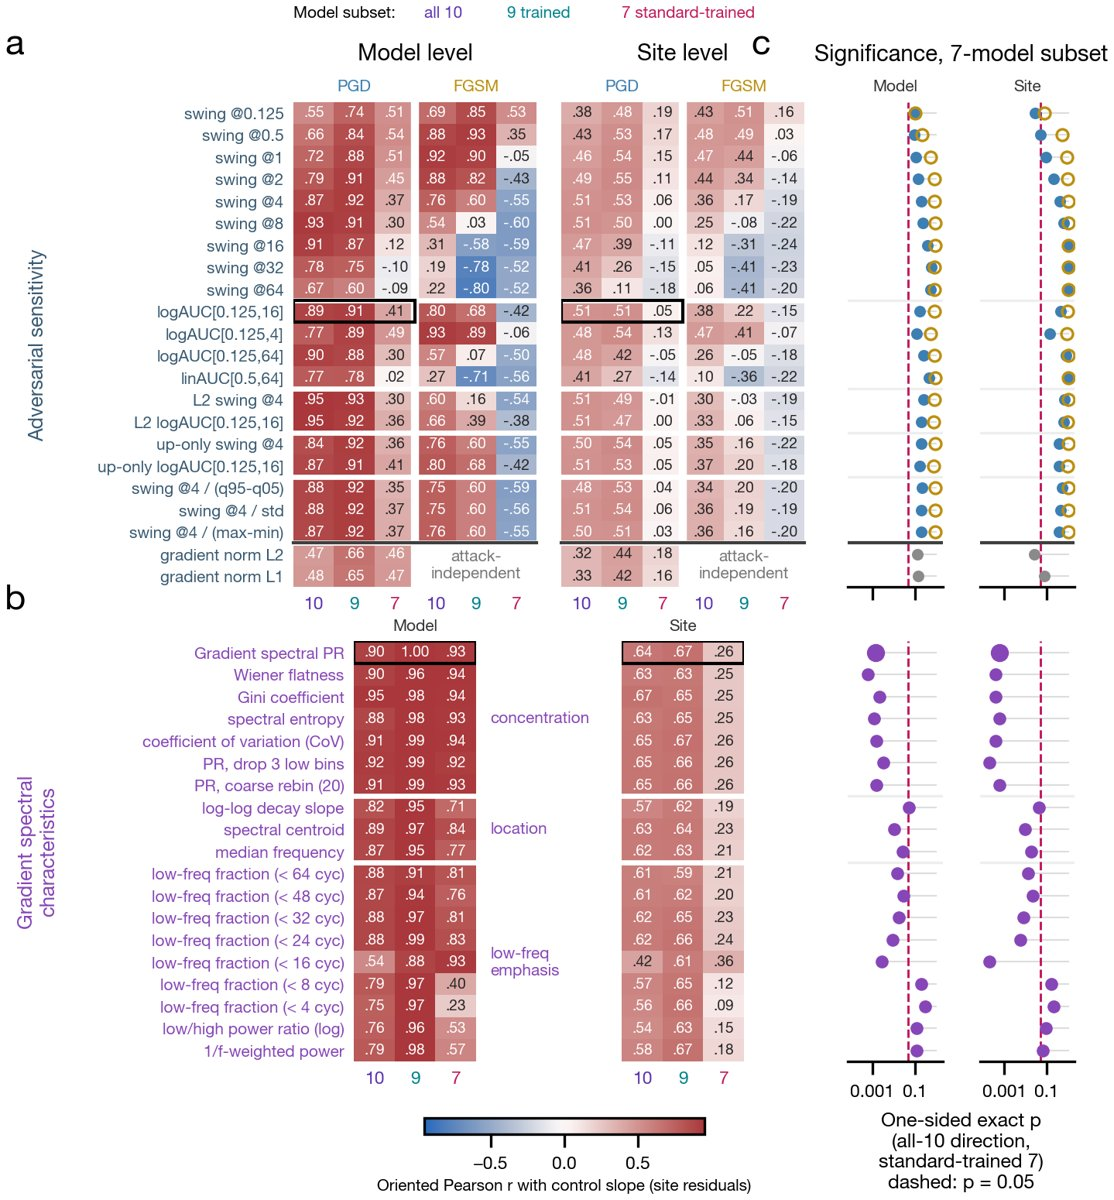

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))